Accepted Data Shape: (10000, 151)
Accepted Data Columns: ['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'd

C:\Users\sheng\AppData\Local\Temp\ipykernel_20184\1706402392.py:27: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  accepted_df = pd.read_csv(ACCEPTED_FILE, nrows=10000)


AttributeError: 'Rectangle' object has no attribute 'get_heights'

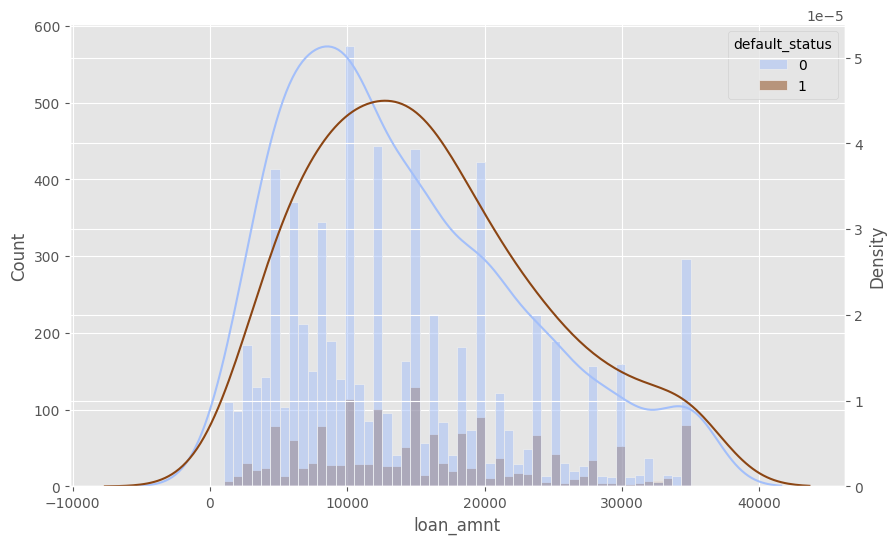

In [15]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plotting style
plt.style.use('ggplot')
sns.set_palette('muted')

# Define paths
DATA_DIR = Path('../Data')
PLOTS_DIR = Path('../Plots')

# Ensure Plots directory exists
PLOTS_DIR.mkdir(exist_ok=True)

# File paths
ACCEPTED_FILE = DATA_DIR / 'accepted_2007_to_2018Q4.csv'
REJECTED_FILE = DATA_DIR / 'rejected_2007_to_2018Q4.csv'
ACCEPTED_CLEANED_FILE = DATA_DIR / 'accepted_cleaned.csv'
APPROVAL_DATA_FILE = DATA_DIR / 'approval_data.csv'

# Cell 2: Load and Sample Data
# Load a sample of accepted loans (10,000 rows to manage memory)
accepted_df = pd.read_csv(ACCEPTED_FILE, nrows=10000)
print("Accepted Data Shape:", accepted_df.shape)
print("Accepted Data Columns:", accepted_df.columns.tolist())

# Load a sample of rejected loans (10,000 rows)
rejected_df = pd.read_csv(REJECTED_FILE, nrows=10000)
print("\nRejected Data Shape:", rejected_df.shape)
print("Rejected Data Columns:", rejected_df.columns.tolist())

# Cell 3: Data Cleaning for Accepted Loans
# Filter loans with completed status (Fully Paid or Charged Off)
accepted_df = accepted_df[accepted_df['loan_status'].isin(['Fully Paid', 'Charged Off'])]

# Create target variable: 0 = Fully Paid, 1 = Charged Off
accepted_df['default_status'] = accepted_df['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})

# Select relevant features
features = ['loan_amnt', 'int_rate', 'grade', 'annual_inc', 'dti', 'fico_range_low', 'delinq_2yrs', 'open_acc', 'revol_bal']
target = 'default_status'

# Handle missing values
print("\nMissing Values in Accepted Data:")
print(accepted_df[features + [target]].isnull().mean())
accepted_df['annual_inc'] = accepted_df['annual_inc'].fillna(accepted_df['annual_inc'].median())
accepted_df['dti'] = accepted_df['dti'].fillna(accepted_df['dti'].median())
accepted_df['grade'] = accepted_df['grade'].fillna(accepted_df['grade'].mode()[0])

# Encode categorical variable
from sklearn.preprocessing import LabelEncoder
accepted_df['grade'] = LabelEncoder().fit_transform(accepted_df['grade'])

# Cell 4: Data Cleaning for Rejected Loans
# Add accepted label (0 = rejected)
rejected_df['accepted'] = 0

# Rename columns to match accepted data
rejected_df = rejected_df.rename(columns={
    'Amount Requested': 'loan_amnt',
    'Debt-To-Income Ratio': 'dti',
    'Employment Length': 'emp_length'
})

# Handle DTI (remove % and convert to float)
rejected_df['dti'] = rejected_df['dti'].str.replace('%', '').astype(float)
rejected_df['dti'] = rejected_df['dti'].fillna(rejected_df['dti'].median())

# Convert emp_length to numeric
def emp_length_to_numeric(emp):
    if pd.isna(emp):
        return 0
    if '10+' in emp:
        return 10
    if '<' in emp:
        return 0
    return int(emp.split()[0])

rejected_df['emp_length'] = rejected_df['emp_length'].apply(emp_length_to_numeric)

# Cell 5: Combine Data for Approval Model
# Add accepted label to accepted data
accepted_df['accepted'] = 1

# Select common features
common_features = ['loan_amnt', 'dti', 'emp_length']
accepted_subset = accepted_df[common_features + ['accepted']]
rejected_subset = rejected_df[common_features + ['accepted']]

# Combine datasets
approval_df = pd.concat([accepted_subset, rejected_subset], ignore_index=True)
print("\nApproval Data Shape:", approval_df.shape)


# Cell 6: Visualization 1 - Loan Amount Distribution
plt.figure(figsize=(10, 6))
# Plot histogram without KDE to avoid rendering issues
sns.histplot(data=accepted_df, x='loan_amnt', hue='default_status', bins=50,
             palette=['#A3BFFA', '#8B4513'])  # Light blue for No Default, brown for Default

# Add KDE lines with a secondary Y-axis and adjusted bandwidth
ax1 = plt.gca()  # Get current axis (histogram)
ax2 = ax1.twinx()  # Create a secondary Y-axis for KDE

# Plot KDE lines with adjusted bandwidth
kde_no_default = sns.kdeplot(data=accepted_df[accepted_df['default_status'] == 0], x='loan_amnt',
                             color='#A3BFFA', ax=ax2, label='No Default (0)', bw_adjust=1.5)
kde_default = sns.kdeplot(data=accepted_df[accepted_df['default_status'] == 1], x='loan_amnt',
                          color='#8B4513', ax=ax2, label='Default (1)', bw_adjust=1.5)

# Calculate scaling factor based on histogram max frequency and KDE max density
hist_max_freq = ax1.get_children()[0].get_heights().max()  # Actual max frequency from histogram
kde_max_density = max([line.get_ydata().max() for line in ax2.get_lines()])  # Max density of KDE lines
scaling_factor = hist_max_freq / kde_max_density * 1.0  # Scale KDE to match histogram peak

# Scale the KDE lines to match the frequency axis
for line in ax2.get_lines():
    line.set_ydata(line.get_ydata() * scaling_factor)

# Customize the plot
plt.title('Loan Amount Distribution by Default Status')
ax1.set_xlabel('Loan Amount')
ax1.set_ylabel('Frequency')
ax2.set_ylabel('Scaled Density')  # Label for the secondary Y-axis
ax2.yaxis.label.set_color('gray')  # Optional: color the density label for clarity
ax2.set_ylim(0, 600)  # Match the frequency range for better visualization

# Ensure legend matches histogram and KDE colors
ax1.legend(title='Default Status', labels=['No Default (0)', 'Default (1)'],
           handles=[plt.Line2D([0], [0], color='#A3BFFA', lw=4),  # Light blue
                    plt.Line2D([0], [0], color='#8B4513', lw=4)])  # Brown
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'loan_amount_distribution.png', dpi=300)
plt.close()


# Cell 7: Visualization 2 - Interest Rate vs. Default Status
plt.figure(figsize=(10, 6))
sns.boxplot(data=accepted_df, x='default_status', y='int_rate')
plt.title('Interest Rate by Default Status')
plt.xlabel('Default Status')
plt.ylabel('Interest Rate (%)')
plt.xticks([0, 1], ['No Default (0)', 'Default (1)'])
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'interest_rate_by_default.png', dpi=300)
plt.close()

# Cell 8: Visualization 3 - Grade Distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=accepted_df, x='grade', hue='default_status')
plt.title('Grade Distribution by Default Status')
plt.xlabel('Grade (Encoded)')
plt.ylabel('Count')
plt.legend(title='Default Status', labels=['No Default (0)', 'Default (1)'])
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'grade_distribution.png', dpi=300)
plt.close()

# Cell 9: Visualization 4 - DTI Distribution for Approval
plt.figure(figsize=(10, 6))
sns.histplot(data=approval_df, x='dti', hue='accepted', bins=50, kde=True)
plt.title('Debt-to-Income Ratio Distribution by Approval Status')
plt.xlabel('Debt-to-Income Ratio (%)')
plt.ylabel('Frequency')
plt.legend(title='Accepted', labels=['Rejected (0)', 'Accepted (1)'])
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'dti_by_approval.png', dpi=300)
plt.close()

# Cell 10: Save Cleaned Data
# Save cleaned accepted data for modeling
accepted_df[features + [target]].to_csv(ACCEPTED_CLEANED_FILE, index=False)
print(f"Saved {ACCEPTED_CLEANED_FILE}")

# Save approval data
approval_df.to_csv(APPROVAL_DATA_FILE, index=False)
print(f"Saved {APPROVAL_DATA_FILE}")